# Airbnb Market Intelligence

# 03 - Multivariate EDA

## Objectives

- Analyze relationships among multiple variables
- Understand pricing patterns
- Compare cities and room types

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/cleaned/listings_cleaned.csv")

print(df.shape)

df.head()

(279712, 32)


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


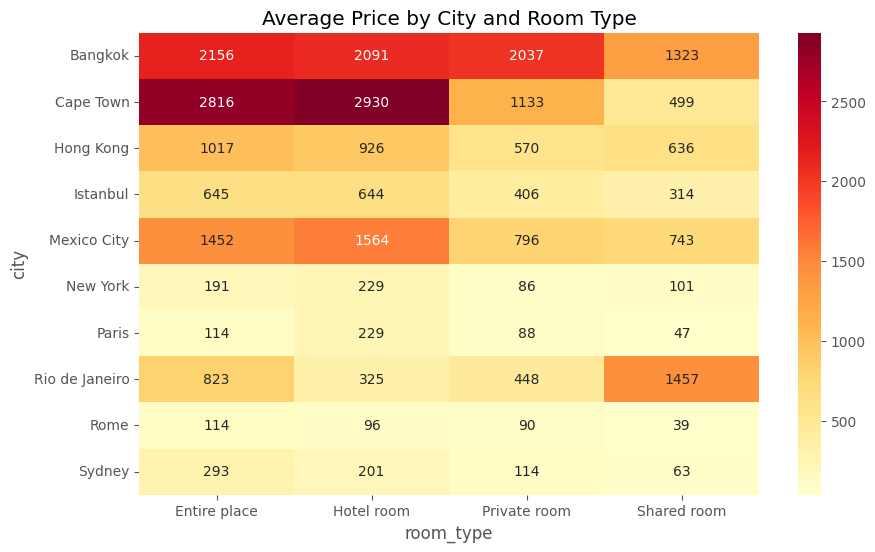

In [3]:
pivot = df.pivot_table(
    values="price",
    index="city",
    columns="room_type",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Average Price by City and Room Type")

plt.show()

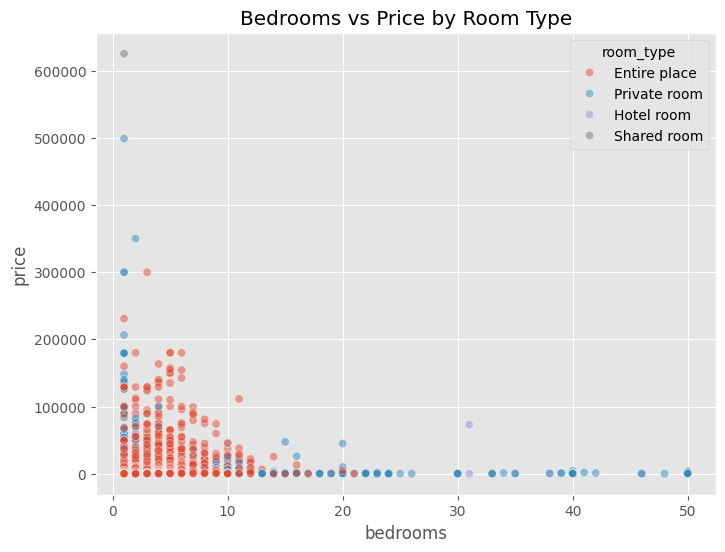

In [4]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="bedrooms",
    y="price",
    hue="room_type",
    alpha=0.5
)

plt.title("Bedrooms vs Price by Room Type")

plt.show()

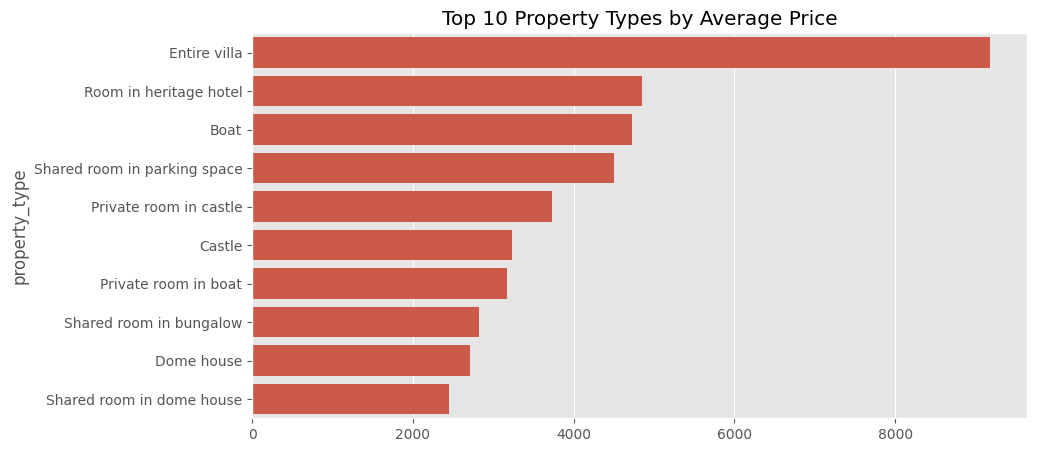

In [5]:
top_property = (
    df.groupby("property_type")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_property.values,
    y=top_property.index
)

plt.title("Top 10 Property Types by Average Price")

plt.show()

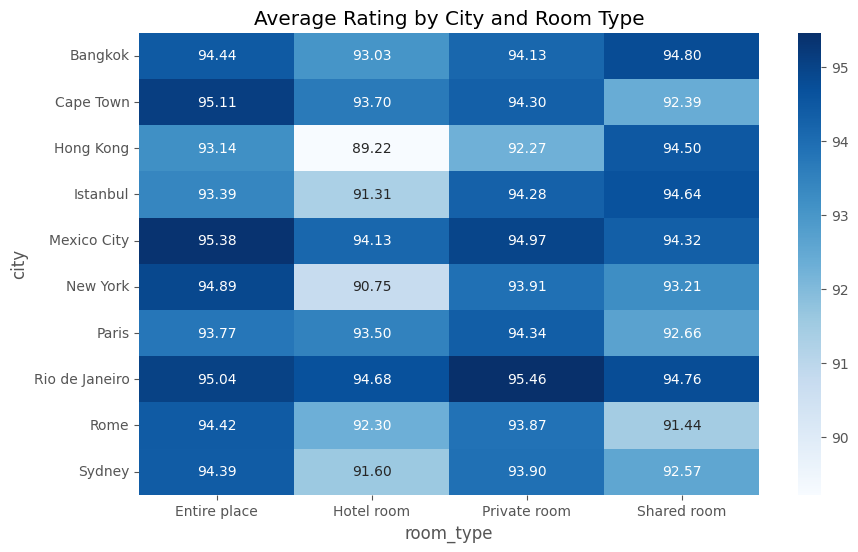

In [6]:
rating = df.pivot_table(
    values="review_scores_rating",
    index="city",
    columns="room_type",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    rating,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Average Rating by City and Room Type")

plt.show()

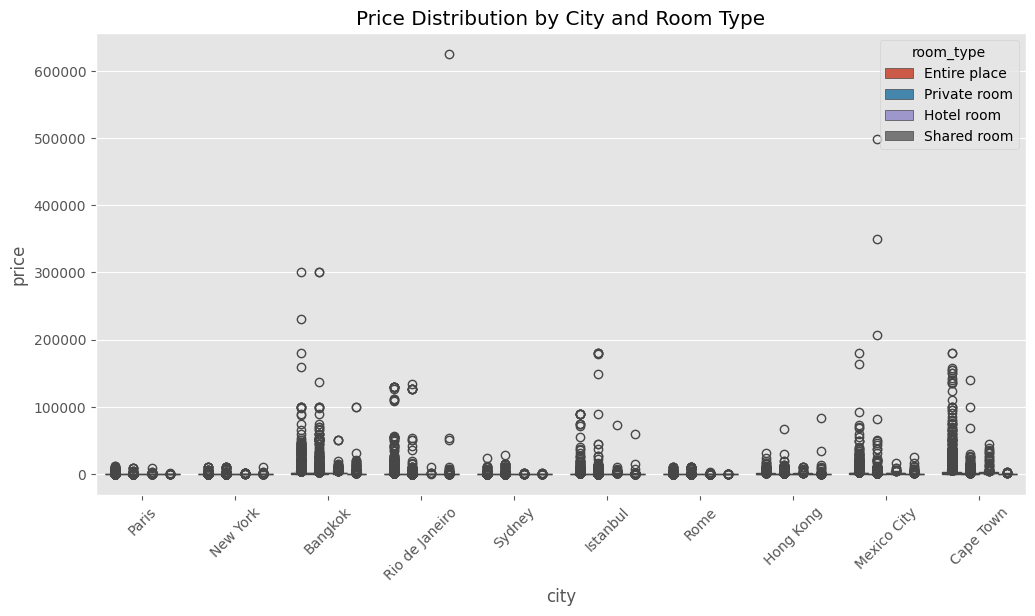

In [7]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="city",
    y="price",
    hue="room_type"
)

plt.xticks(rotation=45)

plt.title("Price Distribution by City and Room Type")

plt.show()

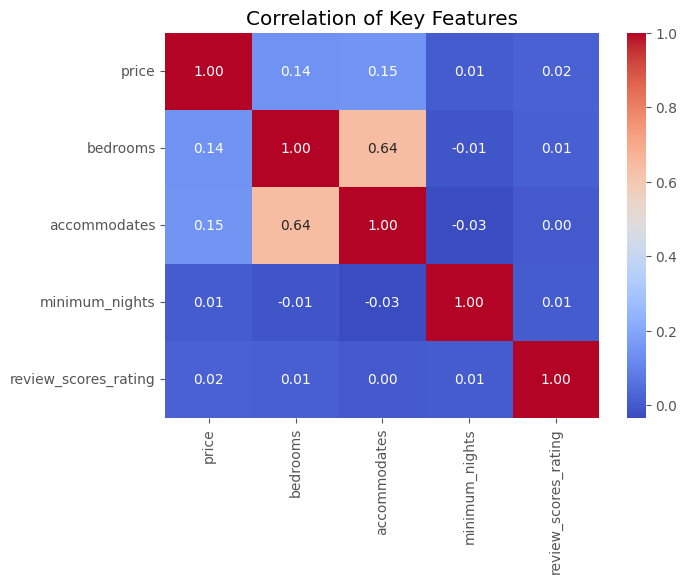

In [8]:
cols = [
    "price",
    "bedrooms",
    "accommodates",
    "minimum_nights",
    "review_scores_rating"
]

plt.figure(figsize=(7,5))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Key Features")

plt.show()

# Business Insights

- Entire homes generally have the highest average prices across cities.
- Listings with more bedrooms tend to command higher prices.
- Property type significantly influences pricing.
- Ratings are consistently high across cities and room types.
- Capacity (bedrooms and accommodates) has a stronger relationship with price than ratings.